In [ ]:
from __future__ import annotations

import os
import sys
import csv
import json
import time
import random
from math import cos, pi
from datetime import datetime
from collections import Counter
from typing import List, Optional, Sequence, Tuple

import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm.auto import tqdm

# Project root setup
PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from configs.config import Config
from models.vit_temporal import ViTS_TemporalTransformer
from utils.device import empty_cache

# Reuse the FaceForensics++ helpers from your evaluation/training scripts.
import test_faceforensics as ffpp
from train_faceforensics import (
    CachedSample,
    FaceForensicsCachedClipDataset,
    cached_samples_to_dataset,
    load_cached_split_manifest_records,
    make_dataset_class_balanced_sampler,
    source_label_summary,
)

In [ ]:
# ============================================================
# USER CONFIG
# ============================================================

RUN_MODE = "train"
# allowed: "prepare_split_only", "train", "test_only"

DATASET_MODE = "hybrid"
# allowed: "ffpp", "celebdf", "hybrid"

FFPP_ROOT = os.path.join(PROJECT_ROOT, "FaceForensics++_C23")
METADATA_CSV = os.path.join(FFPP_ROOT, "csv", "FF++_Metadata.csv")
FFPP_PREPROCESSED_ROOT = os.path.join(FFPP_ROOT, "preprocessed", "faces_v1_224")

CELEBDF_ROOT = os.path.abspath(os.path.join(PROJECT_ROOT, "..", "celebdf"))
CELEBDF_PREPROCESSED_ROOT = os.path.join(CELEBDF_ROOT, "preprocessed", "faces_v1_224")

# Keep False for cached-face training. Raw videos are only supported for FF++-only fallback.
USE_RAW_FFPP = False

DEFAULT_MODEL_NAMES = {
    "ffpp": "FFpp_C23",
    "celebdf": "CelebDF",
    "hybrid": "Hybrid_FFpp_CelebDF",
}
MODEL_NAME = DEFAULT_MODEL_NAMES[DATASET_MODE]

# Cumulative epoch target.
TOTAL_EPOCHS = 15

BATCH_SIZE_OVERRIDE = 4   # 0 = use Config.BATCH_SIZE
SEED = 42

VAL_FRACTION = 0.15
TEST_FRACTION = 0.15

CATEGORIES = ""          # FF++ category filter, e.g. "original,Deepfakes". Empty = all.
MAX_VIDEOS = 0           # Debug cap per dataset/split for cached modes. 0 = all.
SKIP_MISSING = True

NO_PRETRAINED = False    # False = start from ImageNet-pretrained ViT.
NO_RESUME = False         # Fresh hybrid run. Set False later to continue this checkpoint folder.

COOLDOWN_SECONDS = 0     # set >0 if you want pause between epochs
MAKE_PLOTS = False    # Set True only if you want plots after training.

DEVICE_OVERRIDE = ""     # "", "cuda", "cpu", "mps"

VALID_DATASET_MODES = {"ffpp", "celebdf", "hybrid"}
if DATASET_MODE not in VALID_DATASET_MODES:
    raise ValueError(f"DATASET_MODE must be one of {sorted(VALID_DATASET_MODES)}, got {DATASET_MODE!r}")

USE_FFPP_PREPROCESSED = os.path.isdir(FFPP_PREPROCESSED_ROOT) and not USE_RAW_FFPP

In [48]:
def apply_config_model_name(model_name: str) -> str:
    Config.MODEL_NAME = model_name
    Config.CHECKPOINT_DIR = os.path.join(Config.PROJECT_ROOT, "checkpoints", model_name)
    return Config.CHECKPOINT_DIR

CHECKPOINT_DIR = apply_config_model_name(MODEL_NAME)
SPLIT_DIR = os.path.join(CHECKPOINT_DIR, "splits")

TRAIN_CSV = os.path.join(SPLIT_DIR, "train_split.csv")
VAL_CSV = os.path.join(SPLIT_DIR, "val_split.csv")
TEST_CSV = os.path.join(SPLIT_DIR, "test_split.csv")
SPLIT_META_JSON = os.path.join(SPLIT_DIR, "split_meta.json")

RESUME_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint.pt")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pt")

DEVICE = torch.device(DEVICE_OVERRIDE) if DEVICE_OVERRIDE else Config.DEVICE

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)

print("Dataset mode  :", DATASET_MODE)
print("Checkpoint dir:", CHECKPOINT_DIR)
print("Split dir     :", SPLIT_DIR)
print("Device        :", DEVICE)
print("FF++ cache    :", FFPP_PREPROCESSED_ROOT)
if DATASET_MODE in {"celebdf", "hybrid"}:
    print("Celeb-DF root :", CELEBDF_ROOT)
    print("Celeb-DF cache:", CELEBDF_PREPROCESSED_ROOT)

Dataset mode  : hybrid
Checkpoint dir: /Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF
Split dir     : /Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF/splits
Device        : mps
FF++ cache    : /Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/FaceForensics++_C23/preprocessed/faces_v1_224
Celeb-DF root : /Users/krrishkumar/Documents/Personal Learning/BTP/celebdf
Celeb-DF cache: /Users/krrishkumar/Documents/Personal Learning/BTP/celebdf/preprocessed/faces_v1_224


In [49]:
class FaceForensicsClipDataset(Dataset):
    """One clip per video; paths must exist and be readable."""

    def __init__(
        self,
        video_paths: Sequence[str],
        labels: Sequence[int],
        clip_len: int,
        transform: transforms.Compose,
    ):
        if len(video_paths) != len(labels):
            raise ValueError("video_paths and labels length mismatch")
        self.paths = list(video_paths)
        self.labels = list(labels)
        self.clip_len = clip_len
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        path = self.paths[idx]
        frames = ffpp.read_frames_rgb(path)
        if not frames:
            raise ValueError(f"No decodable frames in video: {path}")
        clip = ffpp.frames_to_clip(frames, self.clip_len, self.transform)
        return clip, self.labels[idx]

In [50]:
class AverageMeter:
    def __init__(self) -> None:
        self.reset()

    def reset(self) -> None:
        self.val = 0.0
        self.avg = 0.0
        self.sum = 0.0
        self.count = 0

    def update(self, val: float, n: int = 1) -> None:
        self.val = float(val)
        self.sum += float(val) * n
        self.count += n
        self.avg = self.sum / max(1, self.count)


def calculate_accuracy(outputs: torch.Tensor, targets: torch.Tensor) -> float:
    batch_size = targets.size(0)
    _, pred = outputs.topk(1, 1, True)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1))
    return 100.0 * correct.float().sum().item() / batch_size


def train_epoch(
    epoch: int,
    total_epochs: int,
    data_loader: DataLoader,
    model: nn.Module,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LambdaLR,
    device: torch.device,
) -> Tuple[float, float]:
    model.train()
    losses = AverageMeter()
    accuracies = AverageMeter()

    pbar = tqdm(
        data_loader,
        desc=f"Train {epoch}/{total_epochs}",
        bar_format="{l_bar}{bar:30}{r_bar}",
        leave=True,
    )

    for inputs, targets in pbar:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        losses.update(loss.item(), inputs.size(0))
        accuracies.update(calculate_accuracy(outputs, targets), inputs.size(0))
        pbar.set_postfix_str(f"loss={losses.avg:.4f} acc={accuracies.avg:.2f}%")

    return losses.avg, accuracies.avg


def validate(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    desc: str = "Validate",
) -> Tuple[List[int], List[int], np.ndarray, float, float]:
    model.eval()

    losses = AverageMeter()
    accuracies = AverageMeter()

    true_labels: List[int] = []
    predictions: List[int] = []
    all_probs: List[np.ndarray] = []

    pbar = tqdm(
        data_loader,
        desc=desc,
        bar_format="{l_bar}{bar:30}{r_bar}",
        leave=True,
    )

    with torch.no_grad():
        for inputs, targets in pbar:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, dtype=torch.long, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            probs = torch.softmax(outputs, dim=1)

            true_labels.extend(targets.cpu().numpy().tolist())
            predictions.extend(outputs.argmax(dim=1).cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy())

            losses.update(loss.item(), inputs.size(0))
            accuracies.update(calculate_accuracy(outputs, targets), inputs.size(0))
            pbar.set_postfix_str(f"loss={losses.avg:.4f} acc={accuracies.avg:.2f}%")

    return true_labels, predictions, np.array(all_probs), losses.avg, accuracies.avg


def save_checkpoint(
    checkpoint_dir: str,
    epoch: int,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LambdaLR,
    train_loss_avg: List[float],
    train_accuracy: List[float],
    val_loss_avg: List[float],
    val_accuracy: List[float],
    val_true: Optional[List[int]] = None,
    val_preds: Optional[List[int]] = None,
    val_probs: Optional[np.ndarray] = None,
    best_val_acc: float = 0.0,
    filename: str = "checkpoint.pt",
) -> str:
    os.makedirs(checkpoint_dir, exist_ok=True)
    path = os.path.join(checkpoint_dir, filename)

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "train_loss_avg": train_loss_avg,
            "train_accuracy": train_accuracy,
            "val_loss_avg": val_loss_avg,
            "val_accuracy": val_accuracy,
            "val_true_labels": val_true,
            "val_predictions": val_preds,
            "val_probabilities": val_probs,
            "best_val_acc": best_val_acc,
        },
        path,
    )
    return path


def load_checkpoint(
    path: str,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LambdaLR,
    device: torch.device,
):
    ckpt = torch.load(path, map_location=device, weights_only=False)

    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    return {
        "epoch": ckpt["epoch"],
        "train_loss_avg": ckpt.get("train_loss_avg", []),
        "train_accuracy": ckpt.get("train_accuracy", []),
        "val_loss_avg": ckpt.get("val_loss_avg", []),
        "val_accuracy": ckpt.get("val_accuracy", []),
        "val_true_labels": ckpt.get("val_true_labels"),
        "val_predictions": ckpt.get("val_predictions"),
        "val_probabilities": ckpt.get("val_probabilities"),
        "best_val_acc": ckpt.get("best_val_acc", 0.0),
    }


def cooldown(seconds: int) -> None:
    if seconds <= 0:
        return
    print(f"\nCooldown: waiting {seconds}s")
    for remaining in range(seconds, 0, -1):
        mins, secs = divmod(remaining, 60)
        print(f"\r  {mins:02d}:{secs:02d} remaining", end="", flush=True)
        time.sleep(1)
    print("\r  done                    ")

In [51]:
def norm_abs(path: str) -> str:
    return os.path.normpath(os.path.abspath(path))


def to_rel_if_under_root(path: str, root: str) -> str:
    path = os.path.normpath(path)
    root = os.path.normpath(root)
    if path.startswith(root + os.sep):
        return os.path.relpath(path, root)
    return path


def save_split_csv(csv_path: str, ffpp_root: str, paths: Sequence[str], labels: Sequence[int]) -> None:
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["File Path", "Label"])
        for p, y in zip(paths, labels):
            rel = to_rel_if_under_root(os.path.normpath(p), os.path.normpath(ffpp_root))
            label_str = "FAKE" if y == 0 else "REAL"
            writer.writerow([rel, label_str])


def load_split_csv(csv_path: str, ffpp_root: str) -> Tuple[List[str], List[int]]:
    paths, labels = [], []
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            p = row["File Path"].strip()
            lab = row["Label"].strip().upper()

            full = p if os.path.isabs(p) else os.path.join(ffpp_root, p)
            full = os.path.normpath(full)

            if not os.path.isfile(full):
                raise FileNotFoundError(f"Missing file listed in split CSV: {full}")

            if lab not in {"FAKE", "REAL"}:
                raise ValueError(f"Invalid label '{lab}' in {csv_path}")

            y = 0 if lab == "FAKE" else 1
            paths.append(full)
            labels.append(y)

    return paths, labels


def save_split_metadata(
    json_path: str,
    seed: int,
    val_fraction: float,
    test_fraction: float,
    categories: str,
    max_videos: int,
    train_size: int,
    val_size: int,
    test_size: int,
):
    meta = {
        "seed": seed,
        "val_fraction": val_fraction,
        "test_fraction": test_fraction,
        "categories": categories,
        "max_videos": max_videos,
        "train_size": train_size,
        "val_size": val_size,
        "test_size": test_size,
        "created_at": datetime.now().isoformat(),
    }
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

In [52]:
def collect_samples(
    ffpp_root: str,
    metadata_csv: str,
    categories_filter: Optional[set],
    skip_missing: bool,
    max_total: Optional[int],
    seed: int,
) -> Tuple[List[str], List[int]]:
    rows = ffpp.load_metadata_rows(metadata_csv)

    if categories_filter is not None:
        rows = [r for r in rows if r["category"] in categories_filter]

    paths: List[str] = []
    labels: List[int] = []
    skipped_missing = 0

    for r in rows:
        full = os.path.join(ffpp_root, r["rel_path"])
        full = os.path.normpath(full)

        if not os.path.isfile(full):
            if skip_missing:
                skipped_missing += 1
                continue
            raise FileNotFoundError(f"Video missing: {full}")

        label = 0 if r["label"].upper() == "FAKE" else 1
        paths.append(full)
        labels.append(label)

    if skipped_missing:
        print(f"[Data] Skipped {skipped_missing} missing file(s).")

    if len(set(labels)) < 2:
        raise RuntimeError("Need both FAKE and REAL samples after filtering.")

    if max_total is not None and max_total > 0 and len(paths) > max_total:
        rng = random.Random(seed)
        idx = list(range(len(paths)))
        rng.shuffle(idx)
        idx = idx[:max_total]
        paths = [paths[i] for i in idx]
        labels = [labels[i] for i in idx]
        print(f"[Data] Subsampled to {max_total} videos.")

    return paths, labels


def stratified_train_val_test_split(
    paths: List[str],
    labels: List[int],
    val_fraction: float,
    test_fraction: float,
    seed: int,
) -> Tuple[List[str], List[str], List[str], List[int], List[int], List[int]]:
    if not (0 < val_fraction < 1 and 0 < test_fraction < 1):
        raise ValueError("val_fraction and test_fraction must be in (0,1)")
    if val_fraction + test_fraction >= 1.0:
        raise ValueError("val_fraction + test_fraction must be < 1")

    train_val_p, test_p, train_val_y, test_y = train_test_split(
        paths,
        labels,
        test_size=test_fraction,
        random_state=seed,
        stratify=labels,
    )

    val_ratio_of_remainder = val_fraction / (1.0 - test_fraction)

    train_p, val_p, train_y, val_y = train_test_split(
        train_val_p,
        train_val_y,
        test_size=val_ratio_of_remainder,
        random_state=seed,
        stratify=train_val_y,
    )

    return train_p, val_p, test_p, train_y, val_y, test_y


def prepare_or_load_fixed_splits(
    ffpp_root: str,
    metadata_csv: str,
    categories: str,
    skip_missing: bool,
    max_videos: int,
    seed: int,
    val_fraction: float,
    test_fraction: float,
    train_csv: str,
    val_csv: str,
    test_csv: str,
    split_meta_json: str,
):
    split_files_exist = all(os.path.isfile(p) for p in [train_csv, val_csv, test_csv])

    if split_files_exist:
        print("[Split] Loading existing fixed split CSVs...")
        train_p, train_y = load_split_csv(train_csv, ffpp_root)
        val_p, val_y = load_split_csv(val_csv, ffpp_root)
        test_p, test_y = load_split_csv(test_csv, ffpp_root)
        return train_p, val_p, test_p, train_y, val_y, test_y

    print("[Split] No split CSVs found. Creating fixed train/val/test split now...")

    cats_filter = None
    if categories.strip():
        cats_filter = {c.strip() for c in categories.split(",") if c.strip()}

    max_v = max_videos if max_videos > 0 else None

    paths, labels = collect_samples(
        ffpp_root=ffpp_root,
        metadata_csv=metadata_csv,
        categories_filter=cats_filter,
        skip_missing=skip_missing,
        max_total=max_v,
        seed=seed,
    )

    train_p, val_p, test_p, train_y, val_y, test_y = stratified_train_val_test_split(
        paths=paths,
        labels=labels,
        val_fraction=val_fraction,
        test_fraction=test_fraction,
        seed=seed,
    )

    save_split_csv(train_csv, ffpp_root, train_p, train_y)
    save_split_csv(val_csv, ffpp_root, val_p, val_y)
    save_split_csv(test_csv, ffpp_root, test_p, test_y)

    save_split_metadata(
        split_meta_json,
        seed=seed,
        val_fraction=val_fraction,
        test_fraction=test_fraction,
        categories=categories,
        max_videos=max_videos,
        train_size=len(train_p),
        val_size=len(val_p),
        test_size=len(test_p),
    )

    print("[Split] Saved fixed split CSVs:")
    print("   ", train_csv)
    print("   ", val_csv)
    print("   ", test_csv)

    return train_p, val_p, test_p, train_y, val_y, test_y

In [53]:
cats_filter = {c.strip() for c in CATEGORIES.split(",") if c.strip()} if CATEGORIES.strip() else None
max_items = MAX_VIDEOS if MAX_VIDEOS > 0 else None

train_samples: List[CachedSample] = []
val_samples: List[CachedSample] = []
test_samples: List[CachedSample] = []
train_sampler: Optional[WeightedRandomSampler] = None
split_manifest_path = ""
data_source = ""

if DATASET_MODE == "ffpp" and USE_FFPP_PREPROCESSED:
    assert os.path.isdir(FFPP_PREPROCESSED_ROOT), f"FF++ preprocessed root not found: {FFPP_PREPROCESSED_ROOT}"
    train_samples = load_cached_split_manifest_records(FFPP_PREPROCESSED_ROOT, "train", cats_filter, max_items, SEED, "ffpp")
    val_samples = load_cached_split_manifest_records(FFPP_PREPROCESSED_ROOT, "val", cats_filter, max_items, SEED, "ffpp")
    test_samples = load_cached_split_manifest_records(FFPP_PREPROCESSED_ROOT, "test", cats_filter, max_items, SEED, "ffpp")
    split_manifest_path = os.path.join(FFPP_PREPROCESSED_ROOT, "manifest.csv")
    data_source = "ffpp preprocessed face cache"

elif DATASET_MODE == "ffpp":
    assert os.path.isfile(METADATA_CSV), f"Metadata CSV not found: {METADATA_CSV}"
    assert os.path.isdir(FFPP_ROOT), f"FF++ root not found: {FFPP_ROOT}"

    train_p, val_p, test_p, train_y, val_y, test_y = prepare_or_load_fixed_splits(
        ffpp_root=norm_abs(FFPP_ROOT),
        metadata_csv=norm_abs(METADATA_CSV),
        categories=CATEGORIES,
        skip_missing=SKIP_MISSING,
        max_videos=MAX_VIDEOS,
        seed=SEED,
        val_fraction=VAL_FRACTION,
        test_fraction=TEST_FRACTION,
        train_csv=TRAIN_CSV,
        val_csv=VAL_CSV,
        test_csv=TEST_CSV,
        split_meta_json=SPLIT_META_JSON,
    )
    split_manifest_path = SPLIT_META_JSON
    data_source = "ffpp raw videos"

else:
    if DATASET_MODE == "hybrid":
        assert os.path.isdir(FFPP_PREPROCESSED_ROOT), (
            f"FF++ preprocessed root not found: {FFPP_PREPROCESSED_ROOT}. "
            "Run preprocess_ffpp_faces.py first."
        )
        train_samples.extend(load_cached_split_manifest_records(FFPP_PREPROCESSED_ROOT, "train", cats_filter, max_items, SEED, "ffpp"))
        val_samples.extend(load_cached_split_manifest_records(FFPP_PREPROCESSED_ROOT, "val", cats_filter, max_items, SEED, "ffpp"))
        test_samples.extend(load_cached_split_manifest_records(FFPP_PREPROCESSED_ROOT, "test", cats_filter, max_items, SEED, "ffpp"))

    if DATASET_MODE in {"celebdf", "hybrid"}:
        assert os.path.isdir(CELEBDF_PREPROCESSED_ROOT), (
            f"Celeb-DF preprocessed root not found: {CELEBDF_PREPROCESSED_ROOT}. "
            "Run preprocess_celebdf_faces.py first."
        )
        train_samples.extend(load_cached_split_manifest_records(CELEBDF_PREPROCESSED_ROOT, "train", None, max_items, SEED, "celebdf"))
        val_samples.extend(load_cached_split_manifest_records(CELEBDF_PREPROCESSED_ROOT, "val", None, max_items, SEED, "celebdf"))
        test_samples.extend(load_cached_split_manifest_records(CELEBDF_PREPROCESSED_ROOT, "test", None, max_items, SEED, "celebdf"))

    split_manifest_path = " | ".join(
        part for part in [
            f"ffpp={os.path.join(FFPP_PREPROCESSED_ROOT, 'manifest.csv')}" if DATASET_MODE == "hybrid" else "",
            f"celebdf={os.path.join(CELEBDF_PREPROCESSED_ROOT, 'manifest.csv')}" if DATASET_MODE in {"celebdf", "hybrid"} else "",
        ]
        if part
    )
    data_source = "hybrid ffpp+celebdf preprocessed face caches" if DATASET_MODE == "hybrid" else "celebdf preprocessed face cache"

if train_samples:
    train_p = [sample.cache_dir for sample in train_samples]
    train_y = [sample.label for sample in train_samples]
    val_p = [sample.cache_dir for sample in val_samples]
    val_y = [sample.label for sample in val_samples]
    test_p = [sample.cache_dir for sample in test_samples]
    test_y = [sample.label for sample in test_samples]

def fake_real_counts(ys: Sequence[int]) -> Tuple[int, int]:
    c = Counter(ys)
    return c[0], c[1]

tfk, trk = fake_real_counts(train_y)
vfk, vrk = fake_real_counts(val_y)
xfk, xrk = fake_real_counts(test_y)

print()
print("Fixed split summary")
print("-------------------")
print("Data source:", data_source)
print(f"Train: {len(train_p)}  (FAKE={tfk}, REAL={trk})")
print(f"Val  : {len(val_p)}  (FAKE={vfk}, REAL={vrk})")
print(f"Test : {len(test_p)}  (FAKE={xfk}, REAL={xrk})")
if train_samples:
    print("Train sources:", source_label_summary(train_samples))
    print("Val sources  :", source_label_summary(val_samples))
    print("Test sources :", source_label_summary(test_samples))
print("Split manifest:", split_manifest_path)


Fixed split summary
-------------------
Data source: hybrid ffpp+celebdf preprocessed face caches
Train: 9469  (FAKE=8147, REAL=1322)
Val  : 2030  (FAKE=1746, REAL=284)
Test : 2030  (FAKE=1746, REAL=284)
Train sources: celebdf: FAKE=3947, REAL=622; ffpp: FAKE=4200, REAL=700
Val sources  : celebdf: FAKE=846, REAL=134; ffpp: FAKE=900, REAL=150
Test sources : celebdf: FAKE=846, REAL=134; ffpp: FAKE=900, REAL=150
Split manifest: ffpp=/Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/FaceForensics++_C23/preprocessed/faces_v1_224/manifest.csv | celebdf=/Users/krrishkumar/Documents/Personal Learning/BTP/celebdf/preprocessed/faces_v1_224/manifest.csv


In [54]:
print("Splits/manifests are ready for:", DATASET_MODE)
print("Split manifest:", split_manifest_path)
if DATASET_MODE == "ffpp" and not train_samples:
    print(TRAIN_CSV)
    print(VAL_CSV)
    print(TEST_CSV)

Splits/manifests are ready for: hybrid
Split manifest: ffpp=/Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/FaceForensics++_C23/preprocessed/faces_v1_224/manifest.csv | celebdf=/Users/krrishkumar/Documents/Personal Learning/BTP/celebdf/preprocessed/faces_v1_224/manifest.csv


In [55]:
if RUN_MODE in {"train", "test_only"}:
    tfm = ffpp.build_eval_transform(Config.IM_SIZE, Config.MEAN, Config.STD)

    if train_samples:
        train_ds = cached_samples_to_dataset(
            train_samples,
            Config.CLIP_LEN,
            tfm,
            random_temporal_sampling=True,
            seed=SEED,
        )
        val_ds = cached_samples_to_dataset(val_samples, Config.CLIP_LEN, tfm, False, SEED)
        test_ds = cached_samples_to_dataset(test_samples, Config.CLIP_LEN, tfm, False, SEED)

        if DATASET_MODE == "hybrid":
            train_sampler = make_dataset_class_balanced_sampler(train_samples)
        print("Data source:", data_source)
    else:
        train_ds = FaceForensicsClipDataset(train_p, train_y, Config.CLIP_LEN, tfm)
        val_ds = FaceForensicsClipDataset(val_p, val_y, Config.CLIP_LEN, tfm)
        test_ds = FaceForensicsClipDataset(test_p, test_y, Config.CLIP_LEN, tfm)
        train_sampler = None
        print("Data source: raw videos")

    batch_size = BATCH_SIZE_OVERRIDE if BATCH_SIZE_OVERRIDE > 0 else Config.BATCH_SIZE
    pin_memory = (DEVICE.type == "cuda")

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=train_sampler is None,
        sampler=train_sampler,
        num_workers=Config.NUM_WORKERS,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=Config.NUM_WORKERS,
        pin_memory=pin_memory,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=Config.NUM_WORKERS,
        pin_memory=pin_memory,
    )

    print("Batch size:", batch_size)
    print("Train batches:", len(train_loader))
    print("Val batches  :", len(val_loader))
    print("Test batches :", len(test_loader))
    print("Train sampler:", "dataset+class balanced" if train_sampler is not None else "shuffle")

    sample_x, sample_y = train_ds[0]
    batch_x, batch_y = next(iter(train_loader))
    print("Sample tensor:", tuple(sample_x.shape), "label=", sample_y)
    print("Batch tensor :", tuple(batch_x.shape))
    print("Batch labels :", batch_y.tolist())
    del sample_x, batch_x, batch_y

Data source: hybrid ffpp+celebdf preprocessed face caches
Batch size: 4
Train batches: 2368
Val batches  : 508
Test batches : 508
Train sampler: dataset+class balanced
Sample tensor: (30, 3, 224, 224) label= 0
Batch tensor : (4, 30, 3, 224, 224)
Batch labels : [0, 0, 0, 1]


In [56]:
if RUN_MODE in {"train", "test_only"}:
    model = ViTS_TemporalTransformer(
        num_classes=Config.NUM_CLASSES,
        pretrained=not NO_PRETRAINED,
        temporal_layers=Config.TEMPORAL_LAYERS,
        temporal_heads=Config.TEMPORAL_HEADS,
        temporal_ff=Config.TEMPORAL_FF,
        temporal_dropout=Config.TEMPORAL_DROPOUT,
        t_max=Config.T_MAX,
        use_cls_token=Config.USE_CLS_TOKEN,
    ).to(DEVICE)

    vit_params = model.frame_encoder.parameters()
    temp_head_params = list(model.temporal.parameters()) + list(model.head.parameters())

    optimizer = torch.optim.AdamW(
        [
            {"params": vit_params, "lr": 3e-5},
            {"params": temp_head_params, "lr": 1e-4},
        ],
        weight_decay=Config.WEIGHT_DECAY,
    )

    total_steps = max(1, TOTAL_EPOCHS * max(1, len(train_loader)))
    warmup_steps = int(0.1 * total_steps)

    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return (step + 1) / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + cos(pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
    criterion = nn.CrossEntropyLoss().to(DEVICE)

    train_loss_avg: List[float] = []
    train_accuracy: List[float] = []
    val_loss_avg: List[float] = []
    val_accuracy: List[float] = []
    best_val_acc = 0.0
    start_epoch = 1

    Config.print_config()

/Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


  Configuration
  Platform         : Darwin arm64
  Device           : mps
  Backbone         : vit_small
  Batch size       : 8
  Clip length      : 30
  Num workers      : 0
  Pin memory       : False
  Data dir         : /Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg
  Model name       : Hybrid_FFpp_CelebDF
  Checkpoint dir   : /Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF
  Epochs           : 20
  Learning rate    : 0.0001
  Weight decay     : 0.05
  Image size       : 224
  Num classes      : 2
  Temporal layers  : 4
  Temporal heads   : 6
  CLS token        : True


In [57]:
if RUN_MODE == "train":
    if (not NO_RESUME) and os.path.isfile(RESUME_PATH):
        ckpt_info = load_checkpoint(
            path=RESUME_PATH,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            device=DEVICE,
        )
        start_epoch = int(ckpt_info["epoch"]) + 1
        train_loss_avg = list(ckpt_info["train_loss_avg"])
        train_accuracy = list(ckpt_info["train_accuracy"])
        val_loss_avg = list(ckpt_info["val_loss_avg"])
        val_accuracy = list(ckpt_info["val_accuracy"])
        best_val_acc = float(ckpt_info["best_val_acc"])

        if os.path.isfile(BEST_MODEL_PATH):
            best_ckpt = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
            best_val_acc = max(best_val_acc, float(best_ckpt.get("best_val_acc", 0.0)))

        print(f"Resumed from epoch {start_epoch - 1}")
        print(f"Best val acc so far: {best_val_acc:.2f}%")
    else:
        print("No checkpoint loaded. Training will start from scratch.")

Resumed from epoch 10
Best val acc so far: 92.71%


In [58]:
if RUN_MODE == "train":
    if start_epoch > TOTAL_EPOCHS:
        print(
            f"No training needed: checkpoint is already at epoch {start_epoch - 1}, "
            f"which is >= TOTAL_EPOCHS ({TOTAL_EPOCHS})."
        )
    else:
        print("=" * 70)
        print(f"Training epochs {start_epoch} .. {TOTAL_EPOCHS} on {DEVICE}")
        print("=" * 70)

        last_val_true = None
        last_val_pred = None
        last_val_probs = None

        for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
            t0 = time.time()
            lr_vit = optimizer.param_groups[0]["lr"]
            lr_head = optimizer.param_groups[1]["lr"]

            print("\n" + "─" * 70)
            print(
                f"Epoch {epoch}/{TOTAL_EPOCHS} | "
                f"lr_vit={lr_vit:.2e} | lr_head={lr_head:.2e} | "
                f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
            )
            print("─" * 70)

            tl, ta = train_epoch(
                epoch=epoch,
                total_epochs=TOTAL_EPOCHS,
                data_loader=train_loader,
                model=model,
                criterion=criterion,
                optimizer=optimizer,
                scheduler=scheduler,
                device=DEVICE,
            )
            train_loss_avg.append(tl)
            train_accuracy.append(ta)

            val_true, val_pred, val_probs, vl, va = validate(
                model=model,
                data_loader=val_loader,
                criterion=criterion,
                device=DEVICE,
                desc=f"Val {epoch}/{TOTAL_EPOCHS}",
            )
            val_loss_avg.append(vl)
            val_accuracy.append(va)

            last_val_true = val_true
            last_val_pred = val_pred
            last_val_probs = val_probs

            elapsed = time.time() - t0
            print(f"\nTrain Loss: {tl:.4f} | Train Acc: {ta:.2f}%")
            print(f"Val   Loss: {vl:.4f} | Val   Acc: {va:.2f}%")
            print(f"Time      : {elapsed / 60:.2f} min")

            improved = va > best_val_acc
            if improved:
                best_val_acc = va
                best_path = save_checkpoint(
                    checkpoint_dir=CHECKPOINT_DIR,
                    epoch=epoch,
                    model=model,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    train_loss_avg=train_loss_avg,
                    train_accuracy=train_accuracy,
                    val_loss_avg=val_loss_avg,
                    val_accuracy=val_accuracy,
                    val_true=val_true,
                    val_preds=val_pred,
                    val_probs=val_probs,
                    best_val_acc=best_val_acc,
                    filename="best_model.pt",
                )
                print(f"Best model saved -> {best_path} (Val Acc = {best_val_acc:.2f}%)")
            else:
                print(f"Val acc {va:.2f}% did not improve best {best_val_acc:.2f}%")

            ckpt_path = save_checkpoint(
                checkpoint_dir=CHECKPOINT_DIR,
                epoch=epoch,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                train_loss_avg=train_loss_avg,
                train_accuracy=train_accuracy,
                val_loss_avg=val_loss_avg,
                val_accuracy=val_accuracy,
                val_true=val_true,
                val_preds=val_pred,
                val_probs=val_probs,
                best_val_acc=best_val_acc,
                filename="checkpoint.pt",
            )
            print(f"Checkpoint saved -> {ckpt_path}")

            empty_cache(DEVICE)

            if epoch < TOTAL_EPOCHS and COOLDOWN_SECONDS > 0:
                cooldown(COOLDOWN_SECONDS)

        print("\n" + "=" * 70)
        print("Training complete")
        print(f"Best Val Acc: {best_val_acc:.2f}%")
        print("=" * 70)

        if last_val_true is not None and last_val_pred is not None:
            print("\nValidation classification report (last epoch run in this session):")
            print(
                classification_report(
                    last_val_true,
                    last_val_pred,
                    labels=[0, 1],
                    target_names=["Fake (0)", "Real (1)"],
                    digits=4,
                )
            )

No training needed: checkpoint is already at epoch 10, which is >= TOTAL_EPOCHS (5).


In [59]:
if RUN_MODE in {"train", "test_only"}:
    if os.path.isfile(BEST_MODEL_PATH):
        best_ckpt = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
        model.load_state_dict(best_ckpt["model_state_dict"])
        print(f"Loaded best model from: {BEST_MODEL_PATH}")
        print(f"Stored best val acc   : {best_ckpt.get('best_val_acc', 'n/a')}")
    elif os.path.isfile(RESUME_PATH):
        last_ckpt = torch.load(RESUME_PATH, map_location=DEVICE, weights_only=False)
        model.load_state_dict(last_ckpt["model_state_dict"])
        print("best_model.pt not found, loaded checkpoint.pt instead")
    else:
        raise FileNotFoundError("No best_model.pt or checkpoint.pt found for testing")

    true_te, pred_te, probs_te, loss_te, acc_te = validate(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
        device=DEVICE,
        desc="Held-out Test",
    )

    print("\n" + "=" * 70)
    print("Held-out test set results")
    print("=" * 70)
    print(f"Test loss: {loss_te:.4f}")
    print(f"Test acc : {acc_te:.2f}%")

    # class 0 = FAKE, so probs_te[:, 0] is P(fake)
    p_fake = probs_te[:, 0]
    y_bin = [1 if t == 0 else 0 for t in true_te]

    roc_auc_te = None
    try:
        roc_auc_te = roc_auc_score(y_bin, p_fake)
        print(f"ROC-AUC (FAKE positive, P(fake)): {roc_auc_te:.4f}")
    except ValueError:
        print("ROC-AUC: n/a (single class present in test set)")

    print("\nClassification report (held-out test):")
    report_te = classification_report(
        true_te,
        pred_te,
        labels=[0, 1],
        target_names=["Fake (0)", "Real (1)"],
        digits=4,
    )
    print(report_te)

    test_results_base = f"heldout_test_results_{DATASET_MODE}"
    test_results_npz_path = os.path.join(CHECKPOINT_DIR, f"{test_results_base}.npz")
    test_results_csv_path = os.path.join(CHECKPOINT_DIR, f"{test_results_base}.csv")
    test_metrics_json_path = os.path.join(CHECKPOINT_DIR, f"{test_results_base}_metrics.json")
    test_report_path = os.path.join(CHECKPOINT_DIR, f"{test_results_base}_classification_report.txt")

    true_arr = np.asarray(true_te, dtype=np.int64)
    pred_arr = np.asarray(pred_te, dtype=np.int64)
    probs_arr = np.asarray(probs_te, dtype=np.float32)

    np.savez_compressed(
        test_results_npz_path,
        true=true_arr,
        pred=pred_arr,
        probs=probs_arr,
        loss=np.asarray([loss_te], dtype=np.float32),
        accuracy=np.asarray([acc_te], dtype=np.float32),
        roc_auc=np.asarray([np.nan if roc_auc_te is None else roc_auc_te], dtype=np.float32),
        dataset_mode=np.asarray(DATASET_MODE),
    )

    with open(test_results_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["index", "true_label", "pred_label", "p_fake", "p_real"])
        for idx, (y_true, y_pred, prob) in enumerate(zip(true_arr, pred_arr, probs_arr)):
            writer.writerow([idx, int(y_true), int(y_pred), float(prob[0]), float(prob[1])])

    metrics_payload = {
        "dataset_mode": DATASET_MODE,
        "checkpoint_dir": CHECKPOINT_DIR,
        "best_model_path": BEST_MODEL_PATH if os.path.isfile(BEST_MODEL_PATH) else None,
        "resume_path": RESUME_PATH if os.path.isfile(RESUME_PATH) else None,
        "num_samples": int(len(true_arr)),
        "test_loss": float(loss_te),
        "test_accuracy_percent": float(acc_te),
        "roc_auc_fake_positive": None if roc_auc_te is None else float(roc_auc_te),
        "label_map": {"0": "FAKE", "1": "REAL"},
    }
    with open(test_metrics_json_path, "w", encoding="utf-8") as f:
        json.dump(metrics_payload, f, indent=2)

    with open(test_report_path, "w", encoding="utf-8") as f:
        f.write(report_te)
        f.write("\n")

    print("\nSaved held-out test outputs:")
    print("  NPZ     :", test_results_npz_path)
    print("  CSV     :", test_results_csv_path)
    print("  Metrics :", test_metrics_json_path)
    print("  Report  :", test_report_path)

Loaded best model from: /Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF/best_model.pt
Stored best val acc   : 92.70935960591133


Held-out Test:   5%|█▍                            | 25/508 [00:13<04:27,  1.81it/s, loss=0.0013 acc=100.00%]


KeyboardInterrupt: 

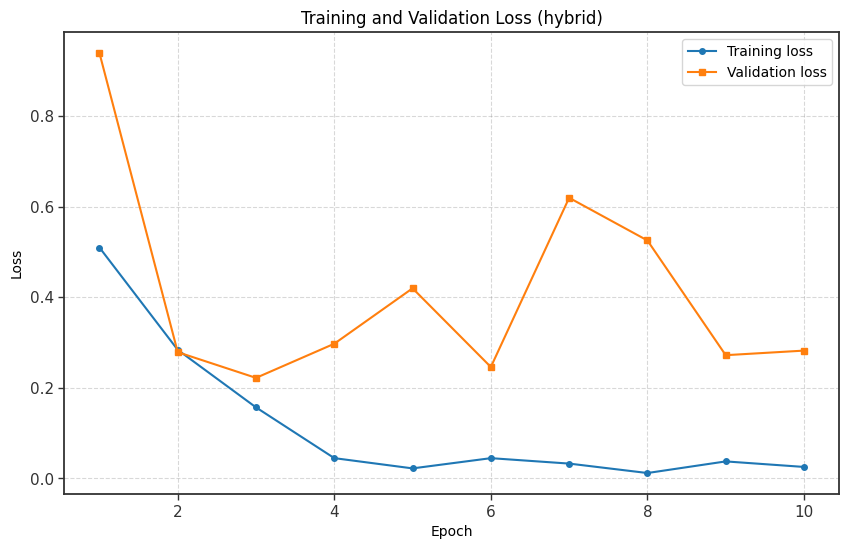

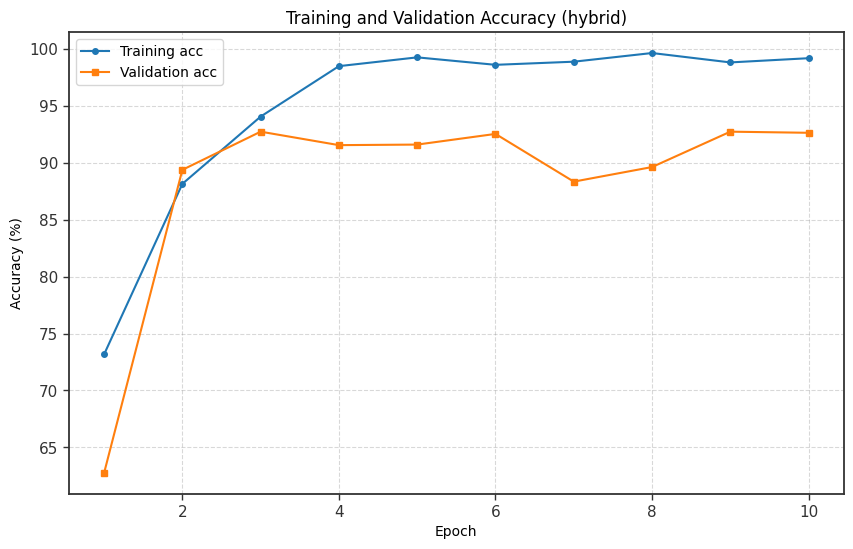

Saved:
/Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF/loss_plot_hybrid.png
/Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF/loss_plot_hybrid.pdf
/Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF/accuracy_plot_hybrid.png
/Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF/accuracy_plot_hybrid.pdf


In [62]:
import matplotlib.pyplot as plt
if os.path.isfile(RESUME_PATH):
    ckpt = torch.load(RESUME_PATH, map_location="cpu", weights_only=False)
    train_loss_plot = ckpt.get("train_loss_avg", [])
    train_acc_plot = ckpt.get("train_accuracy", [])
    val_loss_plot = ckpt.get("val_loss_avg", [])
    val_acc_plot = ckpt.get("val_accuracy", [])
else:
    train_loss_plot = train_loss_avg
    train_acc_plot = train_accuracy
    val_loss_plot = val_loss_avg
    val_acc_plot = val_accuracy

def _style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#333333")
        spine.set_linewidth(1.3)
    ax.tick_params(axis="both", colors="#333333", labelsize=11, length=4, width=1.0)
    ax.grid(True, alpha=0.3, linestyle="--", color="gray")
    ax.set_facecolor("white")

epochs_axis = range(1, len(train_loss_plot) + 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_axis, train_loss_plot, label="Training loss", marker="o", markersize=4)
ax.plot(epochs_axis, val_loss_plot, label="Validation loss", marker="s", markersize=4)
ax.set_title(f"Training and Validation Loss ({DATASET_MODE})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
_style_axes(ax)
ax.legend()
loss_fig_path = os.path.join(CHECKPOINT_DIR, f"loss_plot_{DATASET_MODE}.png")
loss_fig_pdf_path = os.path.join(CHECKPOINT_DIR, f"loss_plot_{DATASET_MODE}.pdf")
fig.savefig(loss_fig_path, dpi=200, bbox_inches="tight")
fig.savefig(loss_fig_pdf_path, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_axis, train_acc_plot, label="Training acc", marker="o", markersize=4)
ax.plot(epochs_axis, val_acc_plot, label="Validation acc", marker="s", markersize=4)
ax.set_title(f"Training and Validation Accuracy ({DATASET_MODE})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
_style_axes(ax)
ax.legend()
acc_fig_path = os.path.join(CHECKPOINT_DIR, f"accuracy_plot_{DATASET_MODE}.png")
acc_fig_pdf_path = os.path.join(CHECKPOINT_DIR, f"accuracy_plot_{DATASET_MODE}.pdf")
fig.savefig(acc_fig_path, dpi=200, bbox_inches="tight")
fig.savefig(acc_fig_pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(loss_fig_path)
print(loss_fig_pdf_path)
print(acc_fig_path)
print(acc_fig_pdf_path)

## ROC Curve And Confusion Matrix

Run this final cell after the held-out test cell has produced `true_te`, `pred_te`, and `probs_te`.

Plotting held-out test ROC curve and confusion matrix...


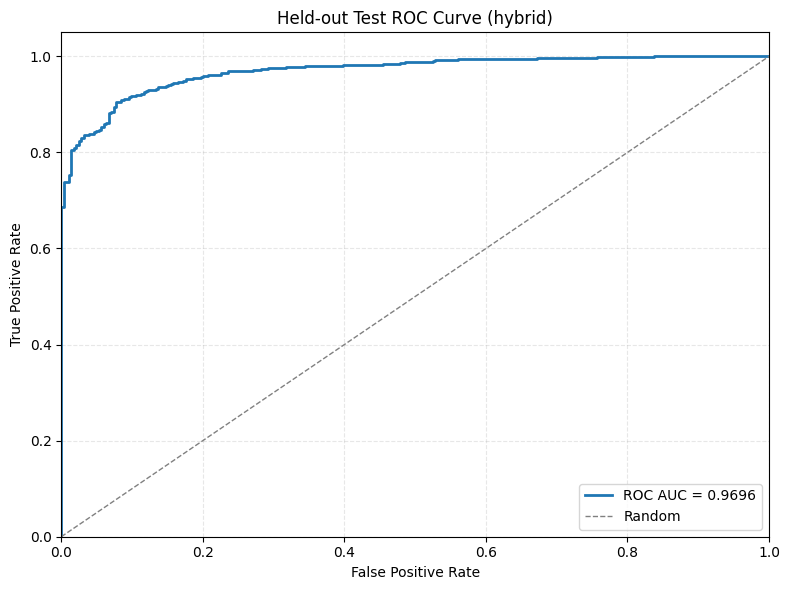

Saved ROC curve PNG: /Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF/roc_curve_hybrid.png
Saved ROC curve PDF: /Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF/roc_curve_hybrid.pdf
Saved ROC points: /Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF/roc_curve_hybrid_points.csv


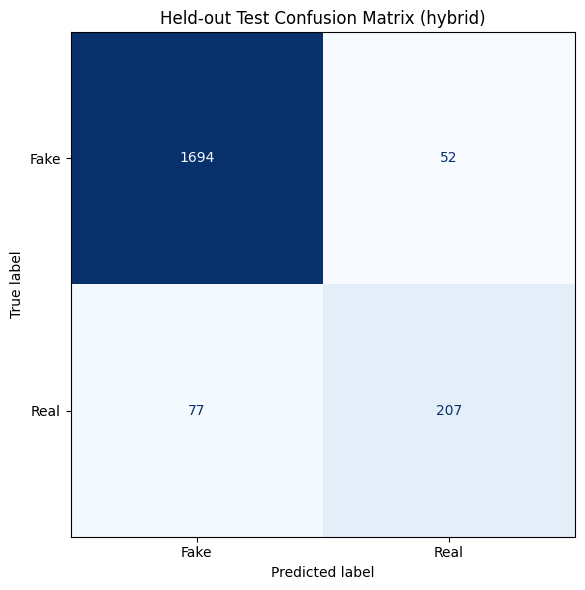

Saved confusion matrix PNG: /Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF/confusion_matrix_hybrid.png
Saved confusion matrix PDF: /Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF/confusion_matrix_hybrid.pdf
Saved confusion matrix CSV: /Users/krrishkumar/Documents/Personal Learning/BTP/Multi-Modal-DeepFake-Detection-using-CNN-RNN-and-Rppg/checkpoints/Hybrid_FFpp_CelebDF/confusion_matrix_hybrid.csv


In [61]:
# ============================================================
# Held-out test ROC curve and confusion matrix
# ============================================================

print("Plotting held-out test ROC curve and confusion matrix...")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

plot_suffix = DATASET_MODE if "DATASET_MODE" in globals() else "run"
test_results_npz_path = os.path.join(CHECKPOINT_DIR, f"heldout_test_results_{plot_suffix}.npz")

required_test_outputs = ["true_te", "pred_te", "probs_te"]
missing_outputs = [name for name in required_test_outputs if name not in globals()]
if missing_outputs:
    if os.path.isfile(test_results_npz_path):
        saved = np.load(test_results_npz_path, allow_pickle=False)
        true_te = saved["true"]
        pred_te = saved["pred"]
        probs_te = saved["probs"]
        print("Loaded saved held-out test outputs:", test_results_npz_path)
    else:
        raise RuntimeError(
            "Run the held-out test cell once before this plotting cell. "
            f"Missing variables: {missing_outputs}. Also not found: {test_results_npz_path}"
        )

true_arr = np.asarray(true_te)
pred_arr = np.asarray(pred_te)
probs_arr = np.asarray(probs_te)

if probs_arr.ndim != 2 or probs_arr.shape[1] < 2:
    raise ValueError(f"Expected probs_te with shape [N, 2], got {probs_arr.shape}")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Class 0 is FAKE, so use P(fake) and treat FAKE as the positive class.
y_fake = (true_arr == 0).astype(int)
p_fake = probs_arr[:, 0]

if len(np.unique(y_fake)) < 2:
    print("ROC curve skipped: held-out test set has only one class.")
else:
    fpr, tpr, _ = roc_curve(y_fake, p_fake)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, linewidth=2, label=f"ROC AUC = {roc_auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="gray", label="Random")
    ax.set_title(f"Held-out Test ROC Curve ({plot_suffix})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)
    ax.grid(alpha=0.3, linestyle="--")
    ax.legend(loc="lower right")
    fig.tight_layout()

    roc_path = os.path.join(CHECKPOINT_DIR, f"roc_curve_{plot_suffix}.png")
    roc_pdf_path = os.path.join(CHECKPOINT_DIR, f"roc_curve_{plot_suffix}.pdf")
    roc_points_path = os.path.join(CHECKPOINT_DIR, f"roc_curve_{plot_suffix}_points.csv")
    fig.savefig(roc_path, dpi=200, bbox_inches="tight")
    fig.savefig(roc_pdf_path, bbox_inches="tight")
    with open(roc_points_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["fpr", "tpr"])
        writer.writerows(zip(fpr.tolist(), tpr.tolist()))
    plt.show()
    print("Saved ROC curve PNG:", roc_path)
    print("Saved ROC curve PDF:", roc_pdf_path)
    print("Saved ROC points:", roc_points_path)

cm = confusion_matrix(true_arr, pred_arr, labels=[0, 1])
fig, ax = plt.subplots(figsize=(6, 6))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title(f"Held-out Test Confusion Matrix ({plot_suffix})")
fig.tight_layout()

cm_path = os.path.join(CHECKPOINT_DIR, f"confusion_matrix_{plot_suffix}.png")
cm_pdf_path = os.path.join(CHECKPOINT_DIR, f"confusion_matrix_{plot_suffix}.pdf")
cm_csv_path = os.path.join(CHECKPOINT_DIR, f"confusion_matrix_{plot_suffix}.csv")
fig.savefig(cm_path, dpi=200, bbox_inches="tight")
fig.savefig(cm_pdf_path, bbox_inches="tight")
with open(cm_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["actual/predicted", "Fake", "Real"])
    writer.writerow(["Fake", int(cm[0, 0]), int(cm[0, 1])])
    writer.writerow(["Real", int(cm[1, 0]), int(cm[1, 1])])
plt.show()
print("Saved confusion matrix PNG:", cm_path)
print("Saved confusion matrix PDF:", cm_pdf_path)
print("Saved confusion matrix CSV:", cm_csv_path)